# Fixation / Eye-Tracking Analysis
**Data:** MonkeyLogic `.mat` file — kikuchi fixation task  
**Signals:** Pupil size (EyeExtra), Gaze position (Eye)  

---

## 0. Imports & Setup

In [40]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

%matplotlib inline
plt.rcParams['figure.dpi'] = 120  # crisper inline plots

## 1. Load Data
Update `MAT_PATH` to point to your `.mat` file.

In [41]:
MAT_PATH = r'/Users/benslates/Library/CloudStorage/OneDrive-NewcastleUniversity/2026_fMRI_PE/fixation-data/260428__kikuchi_fixation_v1_conditions(1).mat'

mat = sio.loadmat(MAT_PATH, simplify_cells=True)

# Top-level keys
print('Top-level keys:', list(mat.keys()))

# Collect all trials
num_trials = len([k for k in mat.keys() if k.startswith('Trial') and k != 'TrialRecord'])
data       = [mat[f'Trial{i+1}'] for i in range(num_trials)]
mlconfig   = mat['MLConfig']

print(f'\nTrials loaded: {num_trials}')
print('Fields in Trial 1:', list(data[0].keys()))

Top-level keys: ['__header__', '__version__', '__globals__', 'MLConfig', 'Trial1', 'Trial2', 'Trial3', 'Trial4', 'Trial5', 'TrialRecord']

Trials loaded: 5
Fields in Trial 1: ['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition', 'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'TrialDateTime', 'BehavioralCodes', 'AnalogData', 'ObjectStatusRecord', 'RewardRecord', 'UserVars', 'VariableChanges', 'TaskObject', 'CycleRate', 'Ver']


## 2. Helper Functions

In [42]:
# ── Parameters ────────────────────────────────────────────────
BASELINE_START_MS = 0      # ms — start of baseline window
BASELINE_END_MS   = 200    # ms — end of baseline window
SMOOTH_WINDOW_MS  = 20     # ms — smoothing kernel
SCREEN_EXTENT_h   = 12     # screen height in degrees (1080 / 45) /2 (resolution / pixels per degree / 2 for +/-)
SCREEN_EXTENT_w   = 21     # screen width in degrees (1920 / 45) /2 (resolution / pixels per degree / 2 for +/-)
FIX_WINDOW        = 2      # degrees — fixation window radius

# Error code labels — adjust to match your task
ERROR_LABELS = {
    0: 'Correct',
    3: 'Broke fixation',
    4: 'No fixation',
}

def get_pupil_trace(trial):
    """Return mean pupil size (width + height averaged) as 1D array."""
    pupil = trial['AnalogData']['EyeExtra']
    if pupil.size == 0 or pupil.ndim < 2:
        return None
    return np.mean(pupil, axis=1)   # Nx2 -> N

def baseline_correct(trace,
                     baseline_start=BASELINE_START_MS,
                     baseline_end=BASELINE_END_MS):
    """Subtract mean of baseline window from entire trace."""
    baseline = np.mean(trace[baseline_start:baseline_end])
    return trace - baseline

print('Helper functions defined.')

Helper functions defined.


## 3. Plot 1 — Mean Pupil Size Per Trial

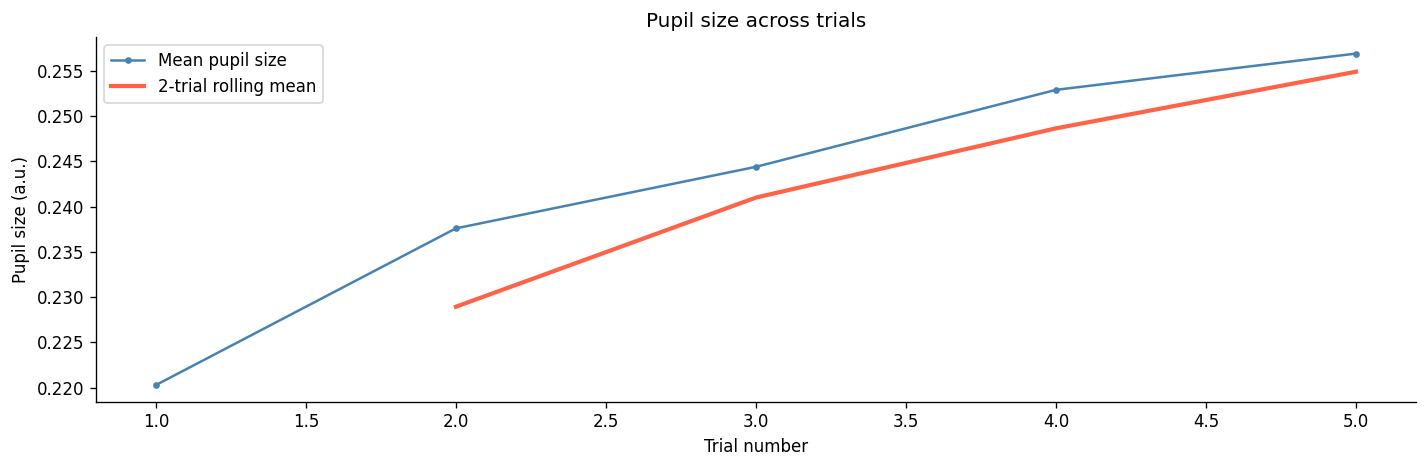

In [49]:
trial_means = []
trial_nums  = []

for t, trial in enumerate(data):
    pupil = get_pupil_trace(trial)
    if pupil is not None and len(pupil) > 0:
        trial_means.append(np.mean(pupil))
        trial_nums.append(t + 1)

trial_means = np.array(trial_means)
trial_nums  = np.array(trial_nums)

# Rolling average
WINDOW = 2
rolling   = np.convolve(trial_means, np.ones(WINDOW) / WINDOW, mode='valid')
rolling_x = trial_nums[WINDOW - 1:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(trial_nums, trial_means, lw=1.5, color='steelblue',
        marker='o', markersize=3, label='Mean pupil size')
ax.plot(rolling_x, rolling, lw=2.5, color='tomato',
        label=f'{WINDOW}-trial rolling mean')
ax.set_xlabel('Trial number')
ax.set_ylabel('Pupil size (a.u.)')
ax.set_title('Pupil size across trials')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Plot 2 — Pupil Heatmap (Time × Trial)

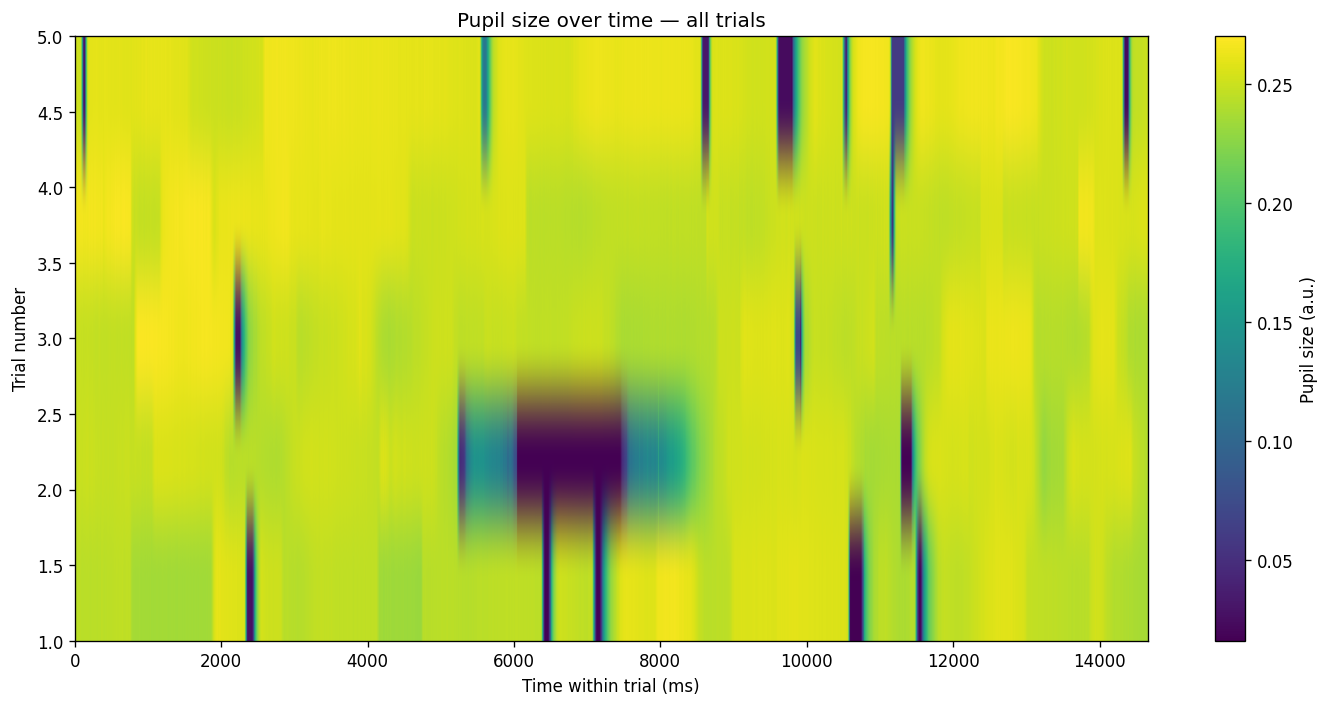

In [44]:
traces = []
for trial in data:
    pupil = get_pupil_trace(trial)
    if pupil is not None and len(pupil) > 0:
        traces.append(pupil)

min_len      = min(len(t) for t in traces)
pupil_matrix = np.array([t[:min_len] for t in traces])  # (n_trials, time)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pupil_matrix, aspect='auto', origin='lower',
               cmap='viridis',
               extent=[0, min_len, 1, len(traces)])
ax.set_xlabel('Time within trial (ms)')
ax.set_ylabel('Trial number')
ax.set_title('Pupil size over time — all trials')
plt.colorbar(im, ax=ax, label='Pupil size (a.u.)')
plt.tight_layout()
plt.show()

## 5. Plot 3 — Baseline-Corrected Pupil Dilation by Condition

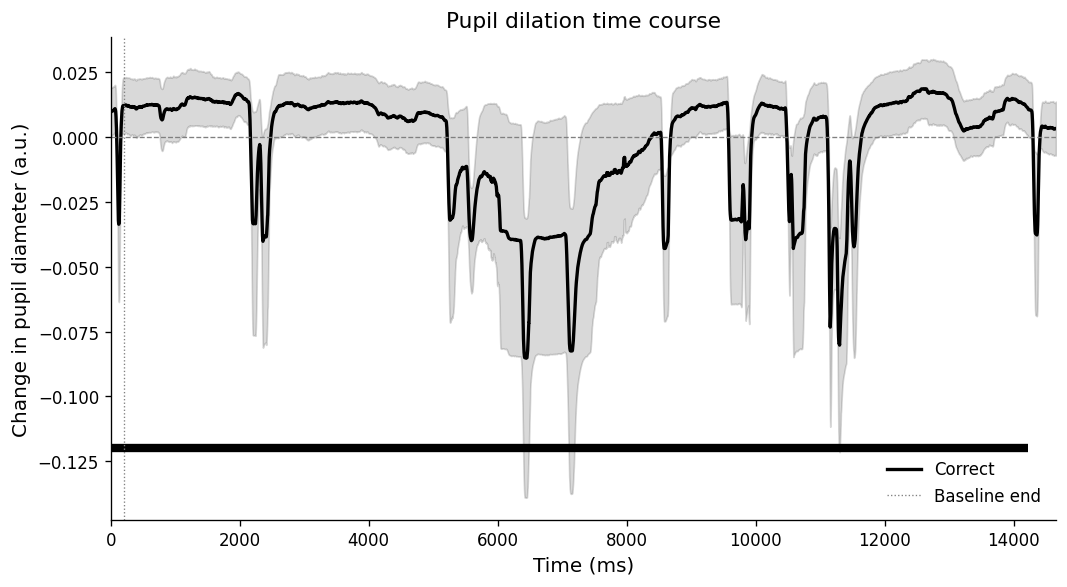

In [45]:
# ── Collect baseline-corrected traces ─────────────────────────
all_traces = []
for trial in data:
    p = get_pupil_trace(trial)
    if p is not None and len(p) > BASELINE_END_MS:
        all_traces.append(baseline_correct(p))

if not all_traces:
    raise ValueError('No valid pupil traces found — check EyeExtra field.')

min_len = min(len(t) for t in all_traces)
time_ms = np.arange(min_len)

# ── Split by TrialError ───────────────────────────────────────
conditions = {}
for trial in data:
    p = get_pupil_trace(trial)
    if p is None or len(p) <= BASELINE_END_MS:
        continue
    key = trial['TrialError']
    conditions.setdefault(key, []).append(baseline_correct(p[:min_len]))

colours = ['black', 'blue', 'green', 'red', 'magenta']
sig_y   = -0.12
sig_step = 0.03

fig, ax = plt.subplots(figsize=(9, 5))

for i, (cond_key, cond_traces) in enumerate(sorted(conditions.items())):
    cond_array  = np.array(cond_traces)
    mean        = np.mean(cond_array, axis=0)
    sem         = np.std(cond_array, axis=0) / np.sqrt(len(cond_array))
    mean_smooth = uniform_filter1d(mean, size=SMOOTH_WINDOW_MS)
    sem_smooth  = uniform_filter1d(sem,  size=SMOOTH_WINDOW_MS)
    colour      = colours[i % len(colours)]
    label       = ERROR_LABELS.get(cond_key, f'Condition {cond_key}')

    ax.plot(time_ms, mean_smooth, lw=2, color=colour, label=label)
    ax.fill_between(time_ms,
                    mean_smooth - sem_smooth,
                    mean_smooth + sem_smooth,
                    color=colour, alpha=0.15)

    # Significance bar (mean > SEM)
    sig_mask = mean_smooth > sem_smooth
    if sig_mask.any():
        sig_times = time_ms[sig_mask]
        ax.hlines(sig_y - i * sig_step,
                  xmin=sig_times[0], xmax=sig_times[-1],
                  colors=colour, linewidth=5)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(BASELINE_END_MS, color='grey', linewidth=0.8,
           linestyle=':', label='Baseline end')
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Change in pupil diameter (a.u.)', fontsize=12)
ax.set_title('Pupil dilation time course', fontsize=13)
ax.set_xlim([0, min_len])
ax.legend(frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Plot 4 — Gaze Traces & Density Heatmap

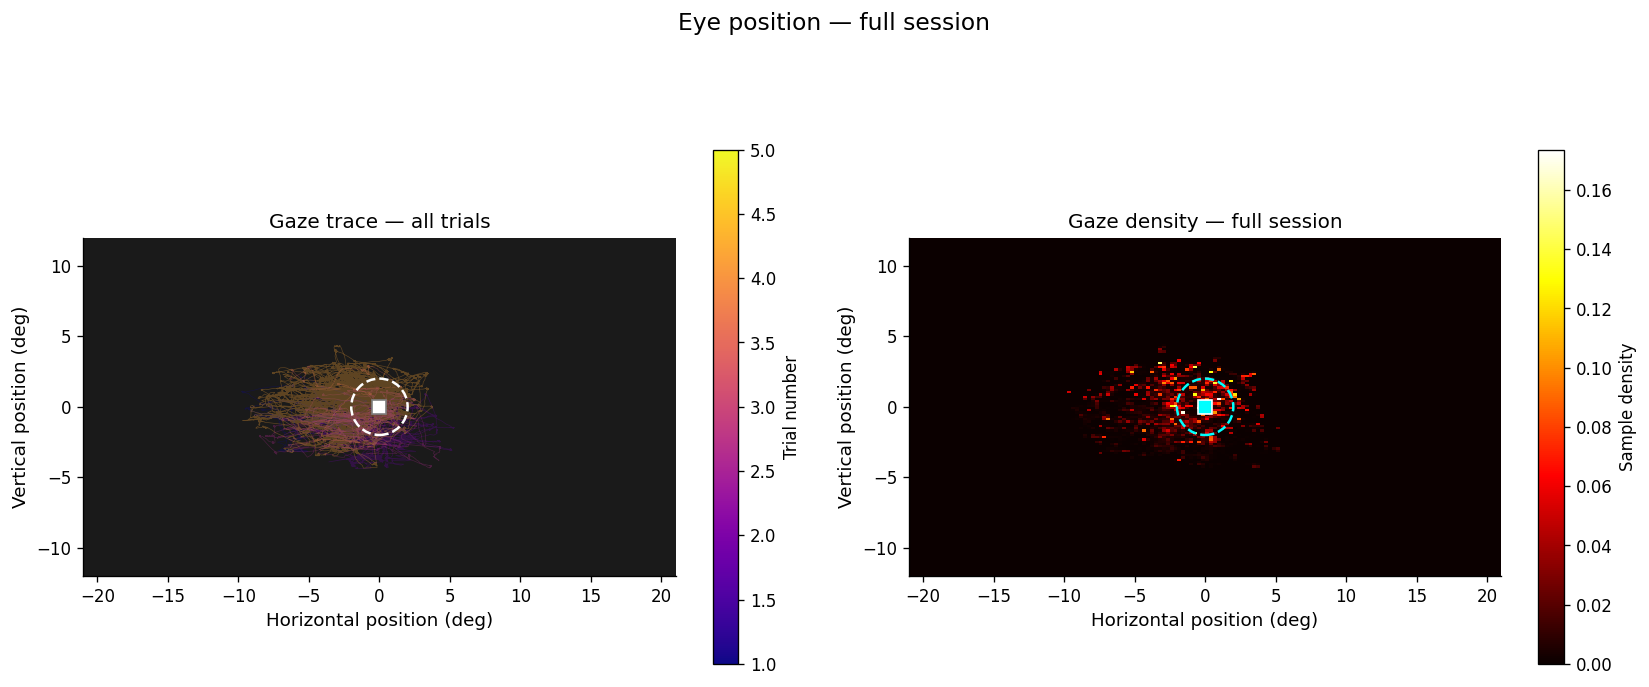

In [46]:
ALPHA = 0.3
CMAP  = 'plasma'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel 1: All trials overlaid, coloured by trial number ────
ax       = axes[0]
cmap_obj = plt.get_cmap(CMAP)
n_plot   = len(data)

for t, trial in enumerate(data):
    eye = trial['AnalogData']['Eye']
    if eye.size == 0 or eye.ndim < 2:
        continue
    ax.plot(eye[:, 0], eye[:, 1],
            lw=0.4, alpha=ALPHA, color=cmap_obj(t / n_plot))

ax.add_patch(plt.Circle((0, 0), FIX_WINDOW,
             fill=False, color='white', lw=1.5, linestyle='--', zorder=5))
ax.plot(0, 0, 's', color='white', markersize=8,
        markeredgecolor='grey', zorder=6)

sm = plt.cm.ScalarMappable(cmap=CMAP,
     norm=plt.Normalize(vmin=1, vmax=n_plot))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Trial number', shrink=0.8)

ax.set_xlim([-SCREEN_EXTENT_w, SCREEN_EXTENT_w])
ax.set_ylim([-SCREEN_EXTENT_h, SCREEN_EXTENT_h])

ax.set_aspect('equal')

ax.set_facecolor('#1a1a1a')
ax.set_xlabel('Horizontal position (deg)', fontsize=11)
ax.set_ylabel('Vertical position (deg)', fontsize=11)
ax.set_title('Gaze trace — all trials', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2: 2D density heatmap ───────────────────────────────
ax = axes[1]

all_x = np.concatenate([trial['AnalogData']['Eye'][:, 0]
                         for trial in data
                         if trial['AnalogData']['Eye'].ndim == 2
                         and trial['AnalogData']['Eye'].size > 0])
all_y = np.concatenate([trial['AnalogData']['Eye'][:, 1]
                         for trial in data
                         if trial['AnalogData']['Eye'].ndim == 2
                         and trial['AnalogData']['Eye'].size > 0])

valid = np.isfinite(all_x) & np.isfinite(all_y)
all_x, all_y = all_x[valid], all_y[valid]

h = ax.hist2d(all_x, all_y,
              bins=150,
              range=[[-SCREEN_EXTENT_w, SCREEN_EXTENT_w],
                     [-SCREEN_EXTENT_h, SCREEN_EXTENT_h]],
              cmap='hot', density=True)

ax.add_patch(plt.Circle((0, 0), FIX_WINDOW,
             fill=False, color='cyan', lw=1.5, linestyle='--', zorder=5))
ax.plot(0, 0, 's', color='cyan', markersize=8,
markeredgecolor='white', zorder=6)

plt.colorbar(h[3], ax=ax, label='Sample density', shrink=0.8)

ax.set_xlim([-SCREEN_EXTENT_w, SCREEN_EXTENT_w])
ax.set_ylim([-SCREEN_EXTENT_h, SCREEN_EXTENT_h])

ax.set_aspect('equal')
ax.set_facecolor('#1a1a1a')

ax.set_xlabel('Horizontal position (deg)', fontsize=11)
ax.set_ylabel('Vertical position (deg)', fontsize=11)
ax.set_title('Gaze density — full session', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Eye position — full session', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()